In [1]:
from pathlib import Path
import sys

from omegaconf import OmegaConf

# Ensure imports work no matter where this notebook is launched from.
project_root = None
for p in [Path.cwd(), *Path.cwd().parents]:
    if (p / "training.py").exists() and (p / "utils").exists():
        project_root = p
        break
if project_root is None:
    raise RuntimeError("Could not locate multiple_token_divergence project root.")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from training import SelfPredictionTrainingRecipeDistributed

model_name = "sibling_discovery_shortcut_PHi_0_1B_h3kwa2lj"
checkpoint_path = project_root / "checkpoints" / model_name

cfg = OmegaConf.load(str(checkpoint_path / "config.yaml"))
cfg.checkpointer.checkpoint_dir = str(checkpoint_path)
cfg.checkpointer.checkpoint_files = ["torchtune_model_last.pt"]

# Inference-safe settings
cfg.optimizer.lr = 0
cfg.compile = False
cfg.train_from_scratch = False
cfg.metric_logger._component_ = "torchtune.training.metric_logging.DiskLogger"

recipe = SelfPredictionTrainingRecipeDistributed(cfg=cfg)
recipe.setup(cfg=cfg)
model = recipe._model.eval()

print("Loaded checkpoint:", str(checkpoint_path / "torchtune_model_last.pt"))

Writing logs to /tmp/self-prediction/log_1774861201.txt


INFO:torchtune.utils._logging:Model is initialized with precision torch.bfloat16.
INFO:torchtune.utils._logging:Memory stats after model init:
	GPU peak memory allocation: 0.20 GiB
	GPU peak memory reserved: 0.21 GiB
	GPU peak memory active: 0.20 GiB
/home/zhank/mtp_runpod/multiple_token_divergence/training.py:1110: FutureWarning: get_world_size_and_rank is deprecated and will be removed in future versions. `get_world_size_and_rank` will move to `torchtune.utils._device` in future releases. Please use `torchtune.utils.get_world_size_and_rank` instead.
  world_size, rank = training.get_world_size_and_rank()
INFO:torchtune.utils._logging:Dataset and Sampler are initialized.
INFO:torchtune.utils._logging:Setting up optimizer for all model parameters.
INFO:torchtune.utils._logging:Optimizer is initialized.
INFO:torchtune.utils._logging:Learning rate scheduler is initialized.
INFO:torchtune.utils._logging:Loss is initialized.
INFO:torchtune.utils._logging: Profiler config after instantiatio

Loaded checkpoint: /home/zhank/mtp_runpod/multiple_token_divergence/checkpoints/sibling_discovery_shortcut_PHi_0_1B_h3kwa2lj/torchtune_model_last.pt


In [2]:
# Evaluate exactly 1 sibling validation sample using the recipe's native loss.
import torch

# Get underlying dataset object
base_dataset = recipe._dataloader.dataset
if hasattr(base_dataset, "ds"):
    base_dataset = base_dataset.ds

base_dataset.split = "validation"
if hasattr(base_dataset, "single_example"):
    base_dataset.single_example = True

sample = base_dataset[0]

tokens = torch.tensor(sample["tokens"], dtype=torch.long, device=recipe._device).unsqueeze(0)
labels = torch.tensor(sample["labels"], dtype=torch.long, device=recipe._device).unsqueeze(0)

with torch.no_grad():
    outputs = recipe._model(tokens=tokens)
    loss_out = recipe._loss_fn(outputs, labels)

if isinstance(loss_out, tuple):
    loss_value, aux_losses = loss_out
else:
    loss_value, aux_losses = loss_out, {}

decoded_in = [recipe._tokenizer.decode([int(t)]) for t in tokens[0].tolist()]
decoded_lbl = [recipe._tokenizer.decode([int(t)]) for t in labels[0].tolist()]

print("split:", base_dataset.split)
print("single_example:", getattr(base_dataset, "single_example", None))
print("num_tokens:", tokens.shape[1])
print("eval_loss:", float(loss_value.detach().cpu()))
print("aux_loss_keys:", list(aux_losses.keys()))
print("\ninput_tokens:", tokens[0].tolist())
print("target_tokens:", labels[0].tolist())
print("decoded_input:", decoded_in)
print("decoded_target:", decoded_lbl)

# Optional: restore defaults
# base_dataset.single_example = False
# base_dataset.split = "train"

split: validation
single_example: True
num_tokens: 4
eval_loss: 5.63284969329834
aux_loss_keys: ['ce_loss', 'phi_loss', 'static_kl_loss', 'self_critic_loss', 'entropy_posterior', 'entropy_prior', 'mse_reconstruction_loss']

input_tokens: [2, 9066, 9751, 653]
target_tokens: [9066, 9751, 653, 3]
decoded_input: ['BOS', '9066 ', '9751 ', '653 ']
decoded_target: ['9066 ', '9751 ', '653 ', 'EOS']


In [3]:
# Compare PHi-layer distribution vs full-model distribution on one sample.
import torch
from modules.self_prediction import gaussian_kl

# Reuse `sample` from previous cell if available, otherwise fetch one.
if "sample" not in globals():
    base_dataset = recipe._dataloader.dataset
    if hasattr(base_dataset, "ds"):
        base_dataset = base_dataset.ds
    base_dataset.split = "validation"
    if hasattr(base_dataset, "single_example"):
        base_dataset.single_example = True
    sample = base_dataset[0]

# Build tensors
x = torch.tensor(sample["tokens"], dtype=torch.long, device=recipe._device).unsqueeze(0)
y = torch.tensor(sample["labels"], dtype=torch.long, device=recipe._device).unsqueeze(0)

with torch.no_grad():
    out = recipe._model(tokens=x)

# In this codebase:
# q_* (posterior) comes from full-model hidden state h
# p_* (prior) comes from the shortcut/PHi prediction path
q_mean = out["q_mean"]
q_logvar = out["q_logvar"]
p_mean = out["p_mean"]
p_logvar = out["p_logvar"]

ignore_index = -100
if hasattr(recipe._loss_fn, "ignore_index"):
    ignore_index = int(recipe._loss_fn.ignore_index)
valid_mask = (y != ignore_index)

# Flatten valid tokens only: [num_valid, d_model]
def flatten_valid(t):
    b, s, d = t.shape
    return t.reshape(b * s, d)[valid_mask.reshape(-1)]

q_mean_v = flatten_valid(q_mean)
q_logvar_v = flatten_valid(q_logvar)
p_mean_v = flatten_valid(p_mean)
p_logvar_v = flatten_valid(p_logvar)

# Aggregate comparisons
summary = {
    "num_valid_tokens": int(q_mean_v.shape[0]),
    "d_model": int(q_mean_v.shape[1]),
    "q_mean_mean": float(q_mean_v.mean().detach().cpu()),
    "p_mean_mean": float(p_mean_v.mean().detach().cpu()),
    "q_logvar_mean": float(q_logvar_v.mean().detach().cpu()),
    "p_logvar_mean": float(p_logvar_v.mean().detach().cpu()),
    "mean_mse": float(torch.mean((q_mean_v - p_mean_v) ** 2).detach().cpu()),
    "logvar_mse": float(torch.mean((q_logvar_v - p_logvar_v) ** 2).detach().cpu()),
    "kl_q_to_p": float(gaussian_kl(p_mean_v.float(), p_logvar_v.float(), q_mean_v.float(), q_logvar_v.float()).mean().detach().cpu()),
    "kl_p_to_q": float(gaussian_kl(q_mean_v.float(), q_logvar_v.float(), p_mean_v.float(), p_logvar_v.float()).mean().detach().cpu()),
}

print("Distribution summary (valid tokens only):")
for k, v in summary.items():
    print(f"{k}: {v}")

print("\nFirst token snapshot (first 8 dims):")
print("q_mean[0,:8]:", q_mean_v[0, :8].detach().cpu().tolist())
print("p_mean[0,:8]:", p_mean_v[0, :8].detach().cpu().tolist())
print("q_logvar[0,:8]:", q_logvar_v[0, :8].detach().cpu().tolist())
print("p_logvar[0,:8]:", p_logvar_v[0, :8].detach().cpu().tolist())

Distribution summary (valid tokens only):
num_valid_tokens: 4
d_model: 768
q_mean_mean: -0.04736328125
p_mean_mean: -0.0400390625
q_logvar_mean: -3.125
p_logvar_mean: -1.8359375
mean_mse: 0.11181640625
logvar_mse: 1.7421875
kl_q_to_p: 545.193115234375
kl_p_to_q: 2141.700927734375

First token snapshot (first 8 dims):
q_mean[0,:8]: [0.1943359375, -0.97265625, 0.423828125, 0.2412109375, 0.154296875, -1.40625, -0.41796875, 0.337890625]
p_mean[0,:8]: [0.21875, -0.4375, 0.0546875, 0.29296875, -0.0849609375, -0.87109375, -0.23046875, 0.185546875]
q_logvar[0,:8]: [-4.25, -4.1875, -4.25, -4.03125, -4.21875, -3.953125, -4.125, -4.21875]
p_logvar[0,:8]: [-2.515625, -2.609375, -2.375, -2.671875, -2.640625, -2.390625, -2.4375, -2.171875]


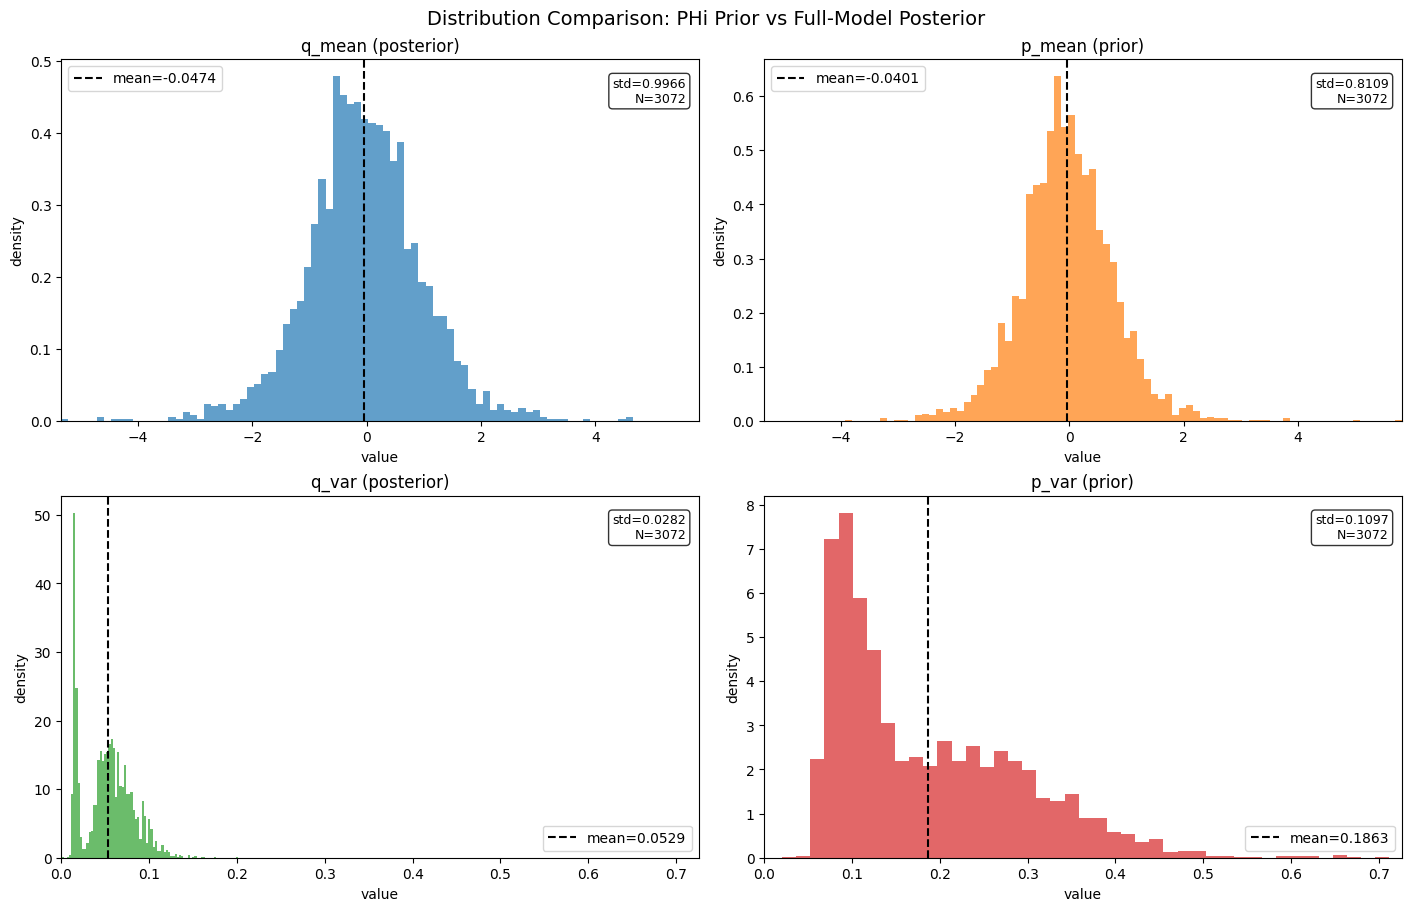

In [10]:
# Visualize distributions of p_mean, q_mean, p_var, q_var.
import numpy as np
import matplotlib.pyplot as plt

# Recompute tensors if they are not already in memory.
if not all(name in globals() for name in ["p_mean_v", "q_mean_v", "p_logvar_v", "q_logvar_v"]):
    if "sample" not in globals():
        base_dataset = recipe._dataloader.dataset
        if hasattr(base_dataset, "ds"):
            base_dataset = base_dataset.ds
        base_dataset.split = "validation"
        if hasattr(base_dataset, "single_example"):
            base_dataset.single_example = True
        sample = base_dataset[0]

    x = torch.tensor(sample["tokens"], dtype=torch.long, device=recipe._device).unsqueeze(0)
    y = torch.tensor(sample["labels"], dtype=torch.long, device=recipe._device).unsqueeze(0)

    with torch.no_grad():
        out = recipe._model(tokens=x)

    q_mean = out["q_mean"]
    q_logvar = out["q_logvar"]
    p_mean = out["p_mean"]
    p_logvar = out["p_logvar"]

    ignore_index = int(recipe._loss_fn.ignore_index) if hasattr(recipe._loss_fn, "ignore_index") else -100
    valid_mask = (y != ignore_index)

    def flatten_valid(t):
        b, s, d = t.shape
        return t.reshape(b * s, d)[valid_mask.reshape(-1)]

    q_mean_v = flatten_valid(q_mean)
    q_logvar_v = flatten_valid(q_logvar)
    p_mean_v = flatten_valid(p_mean)
    p_logvar_v = flatten_valid(p_logvar)

q_var_v = torch.exp(q_logvar_v.float())
p_var_v = torch.exp(p_logvar_v.float())

mean_series = {
    "q_mean (posterior)": q_mean_v.float().detach().cpu().numpy().ravel(),
    "p_mean (prior)": p_mean_v.float().detach().cpu().numpy().ravel(),
}
var_series = {
    "q_var (posterior)": q_var_v.detach().cpu().numpy().ravel(),
    "p_var (prior)": p_var_v.detach().cpu().numpy().ravel(),
}

# Separate shared x-ranges:
# - means keep their natural wide range
# - variances use a wider dedicated range for easier comparison
mean_min = min(np.min(v) for v in mean_series.values())
mean_max = max(np.max(v) for v in mean_series.values())

var_min = 0.0
var_upper = float(np.percentile(np.concatenate(list(var_series.values())), 99.9))
var_max = var_upper * 1.1

fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)
axes = axes.ravel()
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

all_series = {
    **mean_series,
    **var_series,
}

for ax, (name, values), color in zip(axes, all_series.items(), colors):
    ax.hist(values, bins=80, density=True, alpha=0.7, color=color)
    mu = float(values.mean())
    sigma = float(values.std())
    ax.axvline(mu, color="black", linestyle="--", linewidth=1.5, label=f"mean={mu:.4f}")

    if "var" in name:
        ax.set_xlim(var_min, var_max)
    else:
        ax.set_xlim(mean_min, mean_max)

    ax.set_title(name)
    ax.set_xlabel("value")
    ax.set_ylabel("density")
    ax.legend()
    ax.text(
        0.98,
        0.95,
        f"std={sigma:.4f}\nN={values.size}",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=9,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
    )

plt.suptitle("Distribution Comparison: PHi Prior vs Full-Model Posterior", fontsize=14)
plt.show()